In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

master_df = pd.read_csv("master_df.csv")

master_df.head()

,sku_id,units_sold,selling_price,gross_revenue,promo_flag,discount_pct,month,week_ofear,day_of_week,is_weekend,is_festival_month,is_payday_period,season_tag,holiday_flag,weather_index,campaign_intensity,platform_traffic_source,traffic_index,competitor_price_index,competitor_stockout_flag,bundle_offer_flag,stock_visibility_score,rating_score,review_volume,product_visibility_rank,lag_1_units,lag_7_units,lag_30_units,rolling_mean_7,rolling_meN_14,rolling_std_7,current_stock,safety_stock,reorder_point,lead_time_days,inbound_shipment_qty,supplier_id,avg_lead_time,lead_time_variability,target_7d,lag_14_units,lag_21_units,rolling_mean_14,rolling_mean_30,rolling_mean_60,rolling_std_30,rolling_std_60,sku_avg_demand,sku_demand_std,sku_min_demand,sku_max_demand,predicted_demand
0,0,21,1019.22,21403.62,0,0.0162,3,9,4,0,0,1,2,0,1.048713,0,2,0.958559,1.028215,0,0,0.356220,4.99,220,112,22.0,37.0,22.0,30.857143,30.857143,8.153293,963,282,631,10,127,2,10,2,29.0,38.0,26.0,31.785714,29.300000,30.100000,6.894025,7.055951,30.704918,6.810574,18,51,27.251081
1,0,31,944.52,29280.12,0,0.0883,3,9,5,1,0,1,2,1,0.825087,0,2,1.090202,0.998760,0,0,0.393942,4.99,220,21,21.0,25.0,27.0,28.571429,28.571429,8.383658,963,282,631,10,127,2,10,2,27.0,41.0,22.0,30.571429,29.266667,29.983333,6.932847,7.148525,30.704918,6.810574,18,51,26.799505
2,0,28,994.97,27859.16,0,0.0396,3,9,6,1,0,1,2,0,0.984314,0,1,1.061040,1.015025,0,0,0.342863,4.99,220,23,31.0,27.0,31.0,29.428571,29.428571,8.263517,963,282,631,10,127,2,10,2,29.0,26.0,30.0,29.857143,29.400000,30.050000,6.926212,7.138877,30.704918,6.810574,18,51,29.474453
3,0,36,836.26,30105.36,1,0.1928,3,10,0,0,0,1,2,0,1.156903,2,0,1.024165,0.980308,0,0,0.339022,4.99,220,97,28.0,24.0,37.0,29.571429,29.571429,8.223080,963,282,631,10,127,2,10,2,20.0,42.0,35.0,30.000000,29.300000,30.066667,6.923971,7.132800,30.704918,6.810574,18,51,25.439848
4,0,32,968.35,30987.20,0,0.0653,3,10,1,0,0,1,2,0,1.004804,2,0,1.014097,0.993525,0,0,0.394725,4.99,220,4,36.0,41.0,31.0,31.285714,31.285714,8.118175,963,282,631,10,127,2,10,2,29.0,24.0,27.0,29.571429,29.266667,30.183333,6.887937,7.172196,30.704918,6.810574,18,51,29.870531


In [17]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11960 entries, 0 to 11959
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sku_id                    11960 non-null  int64  
 1   units_sold                11960 non-null  int64  
 2   selling_price             11960 non-null  float64
 3   gross_revenue             11960 non-null  float64
 4   promo_flag                11960 non-null  int64  
 5   discount_pct              11960 non-null  float64
 6   month                     11960 non-null  int64  
 7   week_ofear                11960 non-null  int64  
 8   day_of_week               11960 non-null  int64  
 9   is_weekend                11960 non-null  int64  
 10  is_festival_month         11960 non-null  int64  
 11  is_payday_period          11960 non-null  int64  
 12  season_tag                11960 non-null  int64  
 13  holiday_flag              11960 non-null  int64  
 14  weathe

In [18]:
master_df[
    ["sku_id",
     "units_sold",
     "predicted_demand"]
].head()

,sku_id,units_sold,predicted_demand
0,0,21,27.251081
1,0,31,26.799505
2,0,28,29.474453
3,0,36,25.439848
4,0,32,29.870531


In [27]:
inventory_df = (
    master_df
    .groupby("sku_id")
    .agg(
        avg_actual_demand=("units_sold", "mean"),
        avg_predicted_demand=("predicted_demand", "mean"),
        demand_std=("units_sold", "std"),
        current_stock=("current_stock", "last"),
        selling_price=("selling_price", "mean"),
        supplier_id=("supplier_id", "first"),
        lead_time_days=("lead_time_days", "mean"),
        avg_lead_time=("avg_lead_time", "mean"),
        lead_time_variability=("lead_time_variability", "mean"),
        safety_stock=("safety_stock", "last"),
        reorder_point=("reorder_point", "last")
    )
    .reset_index()
)

inventory_df.head()

,sku_id,avg_actual_demand,avg_predicted_demand,demand_std,current_stock,selling_price,supplier_id,lead_time_days,avg_lead_time,lead_time_variability,safety_stock,reorder_point
0,0,30.678930,30.870992,6.704495,963,923.001639,2,10.0,10.0,2.0,282,631
1,1,32.153846,32.134774,8.103550,581,386.001639,6,6.0,6.0,4.0,213,428
2,2,25.946488,26.043583,7.373803,395,223.630401,5,5.0,5.0,2.0,108,259
3,3,28.989967,29.032282,7.178213,375,476.531973,5,5.0,5.0,2.0,113,274
4,4,34.749164,34.887731,7.069214,339,578.502977,7,5.0,5.0,4.0,160,353


In [28]:
inventory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sku_id                 40 non-null     int64  
 1   avg_actual_demand      40 non-null     float64
 2   avg_predicted_demand   40 non-null     float64
 3   demand_std             40 non-null     float64
 4   current_stock          40 non-null     int64  
 5   selling_price          40 non-null     float64
 6   supplier_id            40 non-null     int64  
 7   lead_time_days         40 non-null     float64
 8   avg_lead_time          40 non-null     float64
 9   lead_time_variability  40 non-null     float64
 10  safety_stock           40 non-null     int64  
 11  reorder_point          40 non-null     int64  
dtypes: float64(7), int64(5)
memory usage: 3.9 KB


In [29]:
inventory_df.describe()

,sku_id,avg_actual_demand,avg_predicted_demand,demand_std,current_stock,selling_price,supplier_id,lead_time_days,avg_lead_time,lead_time_variability,safety_stock,reorder_point
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,19.500000,29.666221,29.721264,6.611504,611.375000,859.191570,4.275000,7.425000,7.425000,3.000000,228.600000,474.900000
std,11.690452,3.892680,3.845683,0.749468,310.995398,480.395597,2.459805,3.463269,3.463269,1.012739,112.878605,221.217702
min,0.000000,23.207358,23.391476,5.367766,164.000000,196.371338,0.000000,3.000000,3.000000,2.000000,56.000000,148.000000
25%,9.750000,27.004181,27.043248,6.046377,368.750000,502.987400,2.000000,5.000000,5.000000,2.000000,127.250000,296.750000
50%,19.500000,29.622074,29.762981,6.651204,535.000000,793.048880,4.000000,6.000000,6.000000,3.000000,206.000000,415.500000
75%,29.250000,31.486622,31.504157,7.143648,807.500000,1153.043286,6.000000,10.000000,10.000000,4.000000,312.250000,685.500000
max,39.000000,37.709030,37.570501,8.193058,1166.000000,2119.237224,9.000000,13.000000,13.000000,4.000000,478.000000,874.000000


In [30]:
inventory_df["inventory_status"] = np.where(
    inventory_df["current_stock"] <= inventory_df["reorder_point"],
    "Reorder",
    np.where(
        inventory_df["current_stock"] >
        inventory_df["reorder_point"] * 1.5,
        "Overstock",
        "Optimal"
    )
)

In [31]:
inventory_df["inventory_status"].value_counts()

inventory_status
Optimal      23
Overstock    10
Reorder       7
Name: count, dtype: int64

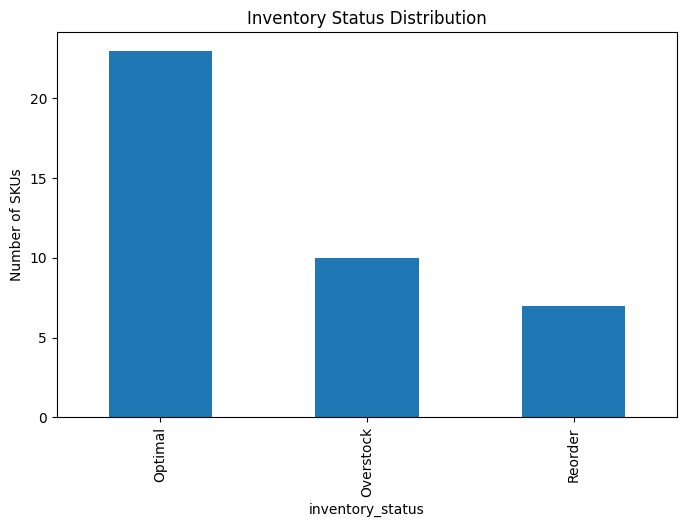

In [32]:
import matplotlib.pyplot as plt

inventory_df["inventory_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Inventory Status Distribution")
plt.ylabel("Number of SKUs")
plt.show()

In [33]:
master_df.rename(
    columns={"week_ofear": "week_of_year"},
    inplace=True
)

In [34]:
inventory_df.to_csv('inventory_df.csv' , index = False)